In [2]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
import scienceplots
import tifffile as tiff

plt.style.use('science')
plt.rcParams["figure.figsize"] = (3.5, 3.5 * ((5**0.5 - 1) / 2)) # 3.5
plt.rcParams["figure.dpi"] = 600
%matplotlib inline

import polars as pl
from polars import Expr, LazyFrame, DataFrame
from pathlib import Path
from typing import Any
import tifffile
from typing import Dict
from typing import Callable
from res import *

combined_mask : has schema Schema({'lod_level': UInt8, 'lod_code': String, 'face': String, 'i': UInt32, 'j': UInt32, 'row_id': UInt32}) and       additional information Parquet SCAN [C:\Users\Joshu\OneDrive - Nexus365\AO33\Boulder_database\AO33-Database-Refinement-Improved\data_products\combined_mask.parquet]
PROJECT */6 COLUMNS
ESTIMATED ROWS: 134519709
combined_atlas : has schema Schema({'face': String, 'i': UInt32, 'j': UInt32, 'uint8_reflectance': UInt8, '32bit_reflectance': Float32, 'positions_x': Float32, 'positions_y': Float32, 'positions_z': Float32}) and       additional information Parquet SCAN [C:\Users\Joshu\OneDrive - Nexus365\AO33\Boulder_database\AO33-Database-Refinement-Improved\data_products\combined_atlas.parquet]
PROJECT */8 COLUMNS
ESTIMATED ROWS: 402653184
mask_atlas_combined : has schema Schema({'lod_level': UInt8, 'lod_code': String, 'face': String, 'i': UInt32, 'j': UInt32, 'row_id': UInt32, 'uint8_reflectance': UInt8, '32bit_reflectance': Float32, 'positions_x'

[]

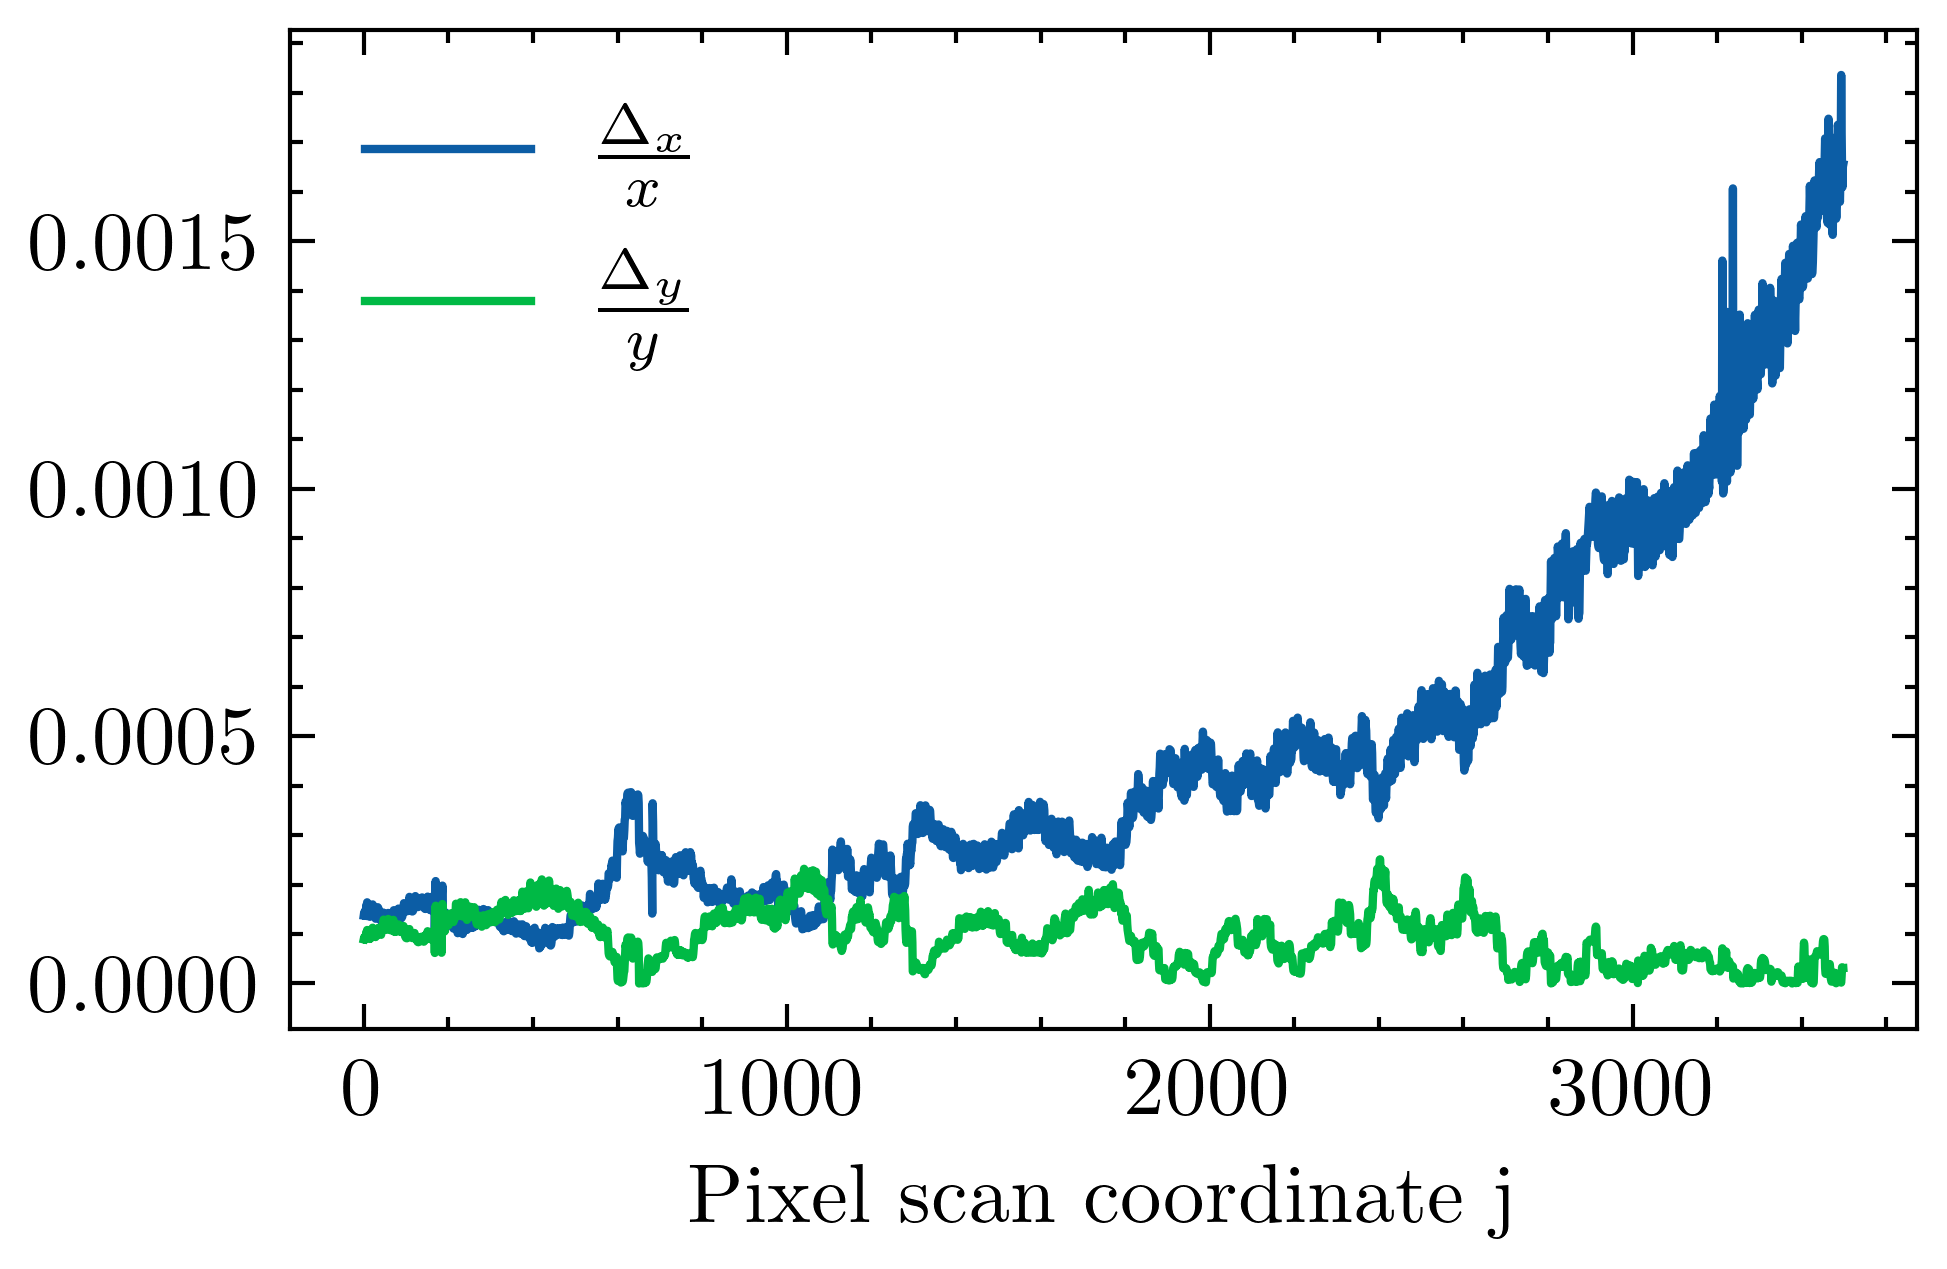

In [3]:
scan: DataFrame = combined_atlas.filter(pl.col("face") == "posx", pl.col("i") == 8192 // 2, pl.col("j") < 3500).sort("j").collect()

i = scan["j"].to_numpy()[:-1]
x, y, z = scan["positions_x"].to_numpy() * 1000, scan["positions_y"].to_numpy() * 1000, scan["positions_z"].to_numpy() * 1000
norm = np.sqrt(x[:-1] ** 2 + y[:-1] ** 2 + z[:-1] ** 2)

plt.plot(i, np.abs(np.diff(x) / x[:-1]), label = r"$\frac{\Delta_x}{x}$")
plt.plot(i, np.abs(np.diff(y) / y[:-1]), label = r"$\frac{\Delta_y}{y}$")
plt.xlabel("Pixel scan coordinate j")
plt.legend()
plt.savefig("r_hat_noise.png")
plt.plot()

In [4]:
Phi_mesh = Phi_mesh.filter(pl.col("area") != 0).with_columns(
    (pl.col("area") * 1e6).alias("area_m_sqr"),
    (pl.col("area") * 1e10).alias("area_cm_sqr"),    (1 / (pl.col("area") * 1e6)).alias("Phi")
    )

Phi_sphere = Phi_sphere.filter(pl.col("area") != 0).with_columns(
    (pl.col("area") * 1e6).alias("area_m_sqr"),
    (pl.col("area") * 1e10).alias("area_cm_sqr"),
    (1 / (pl.col("area") * 1e6)).alias("Phi_o")
    )

Phi_sphere.filter(pl.col("i") == 300).collect()

face,i,j,area,area_m_sqr,area_cm_sqr,Phi_o
str,i32,u32,f32,f32,f32,f32
"""negx""",300,20,1.2581e-8,0.012581,125.807404,79.48658
"""negx""",300,47,1.3046e-8,0.013046,130.458221,76.652893
"""negx""",300,63,1.3017e-8,0.013017,130.173996,76.820259
"""negx""",300,88,1.3197e-8,0.013197,131.967773,75.776077
"""negx""",300,97,1.1897e-8,0.011897,118.969849,84.054909
…,…,…,…,…,…,…
"""posz""",300,8155,1.3110e-8,0.01311,131.09584,76.280067
"""posz""",300,8176,1.1436e-8,0.011436,114.360909,87.442467
"""posz""",300,8184,1.3362e-8,0.013362,133.61734,74.840584


In [5]:
xs = (pl.col("j").cast(pl.Float64) - 4096) / 4096
ys = (pl.col("i").cast(pl.Float64) - 4096) / 4096
r = (xs ** 2 + ys ** 2).sqrt()

Phi_t = (32 * (np.pi / 6) * (1 + r ** 2).pow(3/2))
Phi_s = (pl.col("Phi") * Phi_t) / pl.col("Phi_o")


combined_Phi = Phi_mesh.join(
    Phi_sphere.select(["Phi_o", "face", "i", "j"]), on=["face", "i", "j"], how="inner"
).with_columns(
    Phi_t.alias("Phi_t"),
    Phi_s.alias("Phi_s"),
    r.alias("r")
)

combined_Phi.filter(pl.col("i") == 3004).collect()

face,i,j,area,area_m_sqr,area_cm_sqr,Phi,Phi_o,Phi_t,Phi_s,r
str,i32,u32,f32,f32,f32,f32,f32,f64,f64,f64
"""negx""",3004,9,1.3721e-9,0.001372,13.721066,728.806335,48.433216,49.78065,749.082059,1.032805
"""negx""",3004,66,1.2570e-9,0.001257,12.569701,795.563843,52.328491,48.787595,741.730669,1.019367
"""negx""",3004,81,1.2987e-9,0.001299,12.987458,769.973633,49.798546,48.529682,750.354749,1.015833
"""negx""",3004,112,1.3270e-9,0.001327,13.270444,753.554321,49.265106,48.001141,734.220824,1.008532
"""negx""",3004,115,1.4319e-9,0.001432,14.319092,698.368347,45.64732,47.950311,733.602311,1.007826
…,…,…,…,…,…,…,…,…,…,…
"""posz""",3004,8052,1.5280e-9,0.001528,15.279992,654.450623,47.099087,47.528913,660.423135,1.001941
"""posz""",3004,8066,1.5867e-9,0.001587,15.866581,630.255493,46.210052,47.764416,651.455339,1.005236
"""posz""",3004,8088,1.5156e-9,0.001516,15.155971,659.805969,47.551777,48.136962,667.925716,1.010416


[]

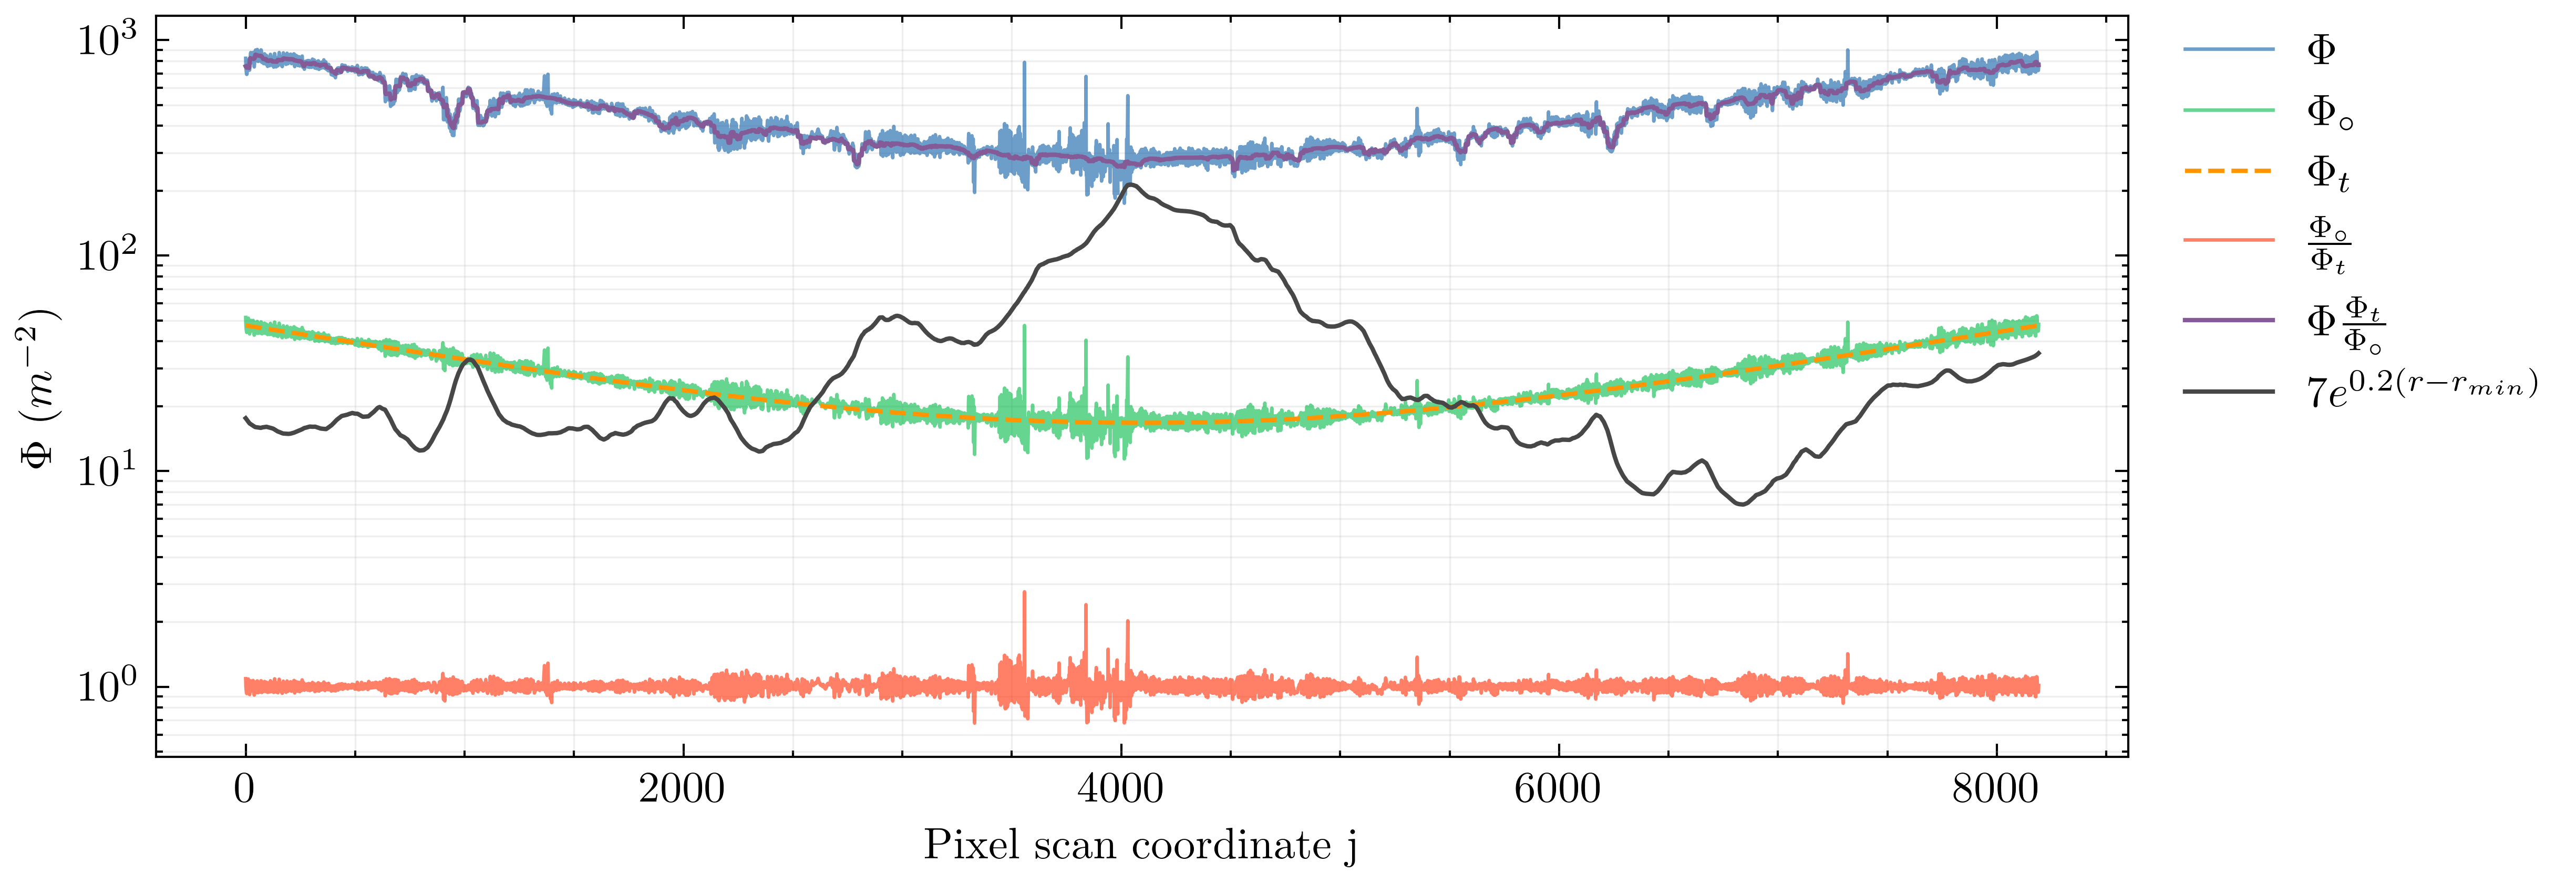

In [6]:
face = "negy"

line_scan_combined = combined_Phi.filter(pl.col("face") == face, pl.col("i") == 8192 // 2 + 5).sort("j").collect()
CA = combined_atlas.filter(pl.col("face") == face, pl.col("i") == 8192 // 2 + 5).sort("j").collect()

Phi_t = line_scan_combined["Phi_t"].to_numpy()
Phi_o = line_scan_combined["Phi_o"].to_numpy()
Phi = line_scan_combined["Phi"].to_numpy()
Phi_s = line_scan_combined["Phi_s"].to_numpy()

noise = Phi_o / Phi_t
x, y, z= CA["positions_x"].to_numpy(), CA["positions_y"].to_numpy(), CA["positions_z"].to_numpy()
r = np.sqrt(x ** 2 + y ** 2 + z ** 2) * 1000
r_min = np.min(r)
r_diff = 7 * np.exp(0.2 * (r - r_min))

plt.figure(figsize=(3.5 * 2, 3), dpi=600)

plt.plot(line_scan_combined["j"].to_numpy(), Phi, label = r"$\Phi$", alpha=0.6, linewidth=0.8)
plt.plot(line_scan_combined["j"].to_numpy(), Phi_o, label = r"$\Phi_{\circ}$", alpha=0.6, linewidth=0.8)
plt.plot(line_scan_combined["j"].to_numpy(), Phi_t, label = r"$\Phi_{t}$", linestyle = "--")

plt.plot(line_scan_combined["j"].to_numpy(), noise, label = r"$\frac{\Phi_{\circ}}{\Phi_{t}}$", alpha=0.6, linewidth=0.8)
plt.plot(line_scan_combined["j"].to_numpy(), Phi_s, label = r"$\Phi \frac{\Phi_{t}}{\Phi_{\circ}}$")
plt.plot(line_scan_combined["j"].to_numpy(), r_diff, label = r"$7 e^{0.2(r - r_{min})}$", linestyle = "-")

plt.yscale("log")
plt.grid(which='minor', linestyle='-', linewidth=0.4, alpha=0.2)
plt.xlabel("Pixel scan coordinate j")
plt.ylabel(r"$\Phi$ ($m^{-2}$)")
plt.tight_layout()
plt.legend(loc='upper left',
          bbox_to_anchor=(1.02, 1),
          borderaxespad=0,
          frameon=False)
plt.savefig("Phi_calibration.png")
plt.plot()

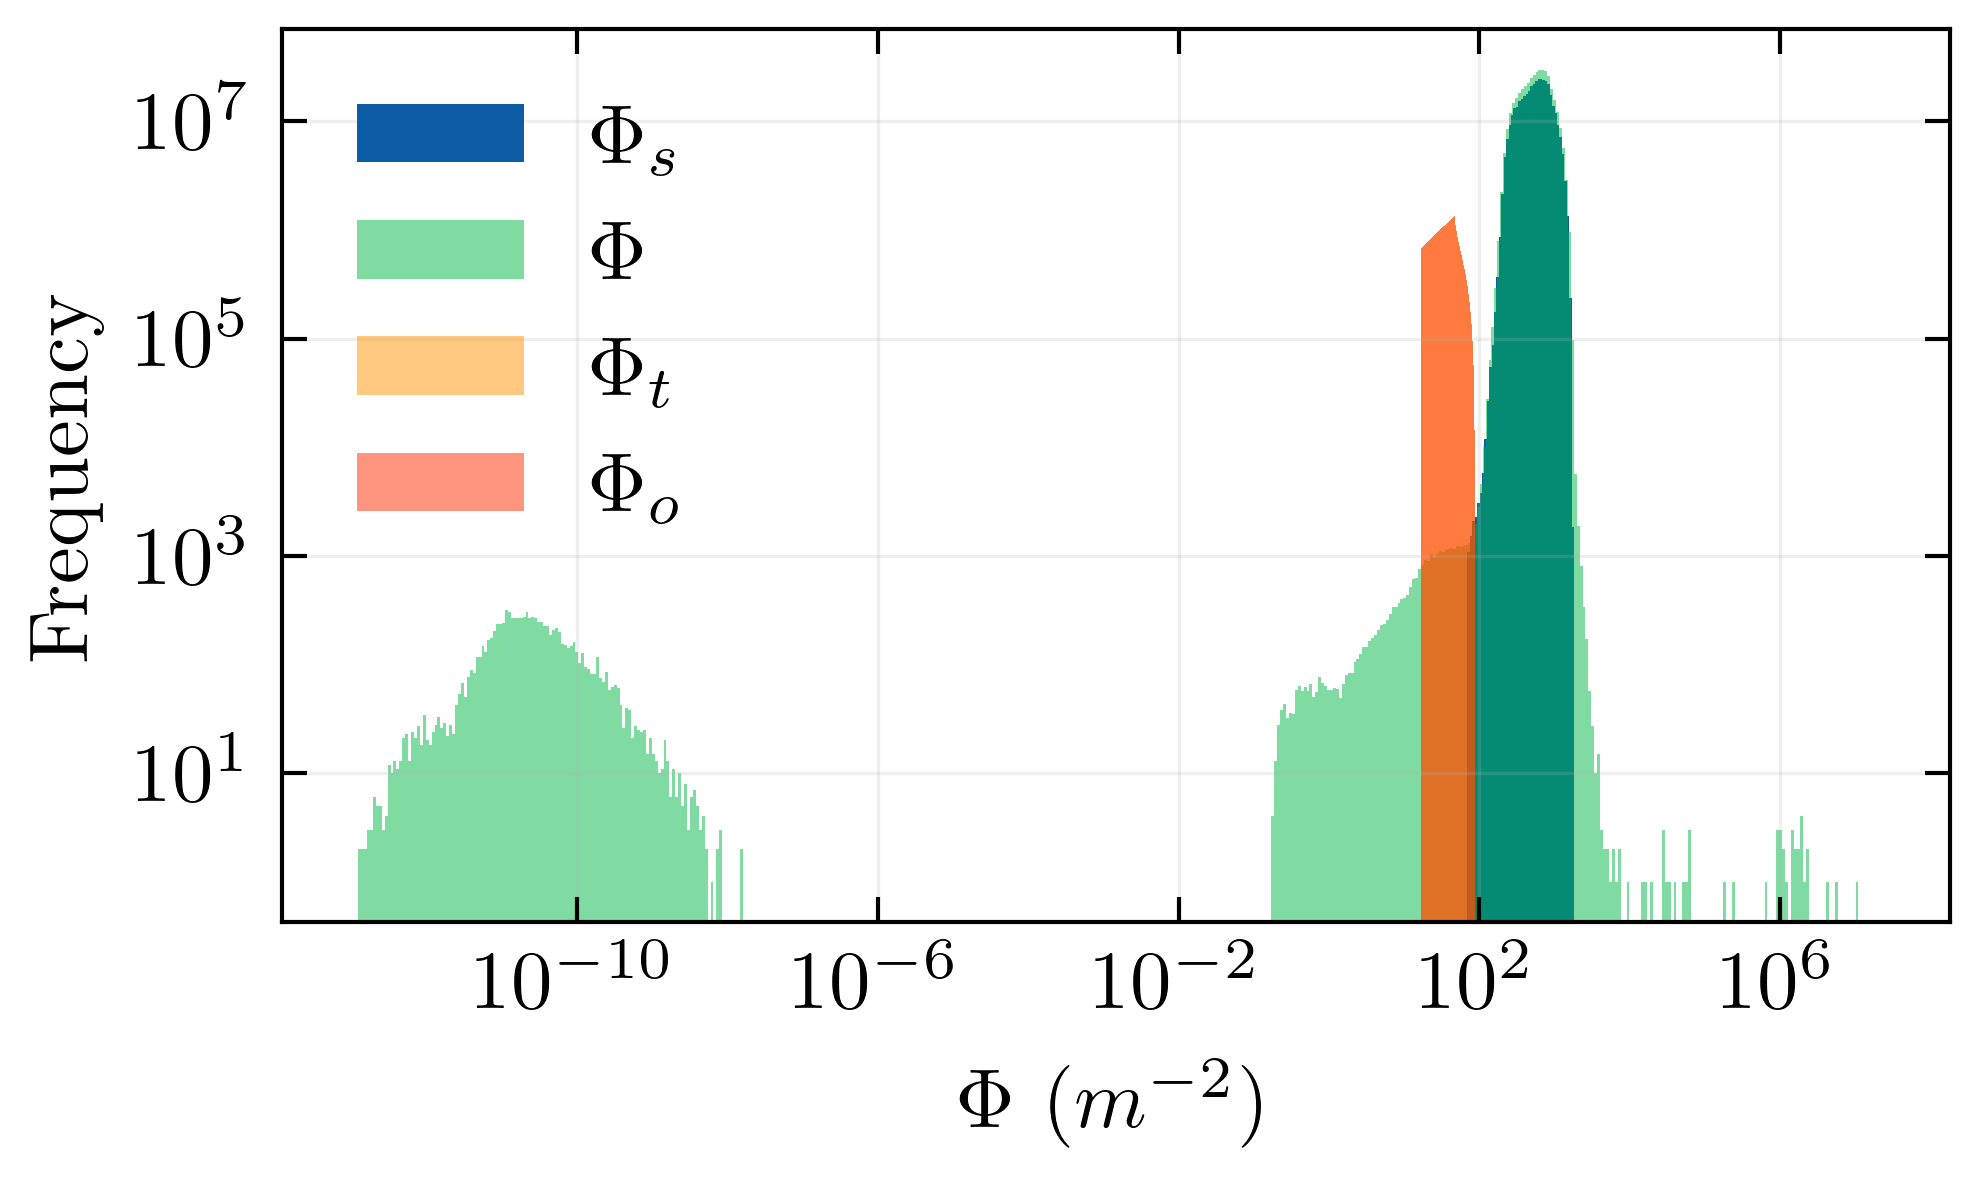

In [21]:
plt.bar(x=Phi_counts_smoothed_bins[:-1], height=np.where(Phi_counts_smoothed_counts < 1e3, 0, Phi_counts_smoothed_counts), width=np.diff(Phi_counts_smoothed_bins), align='edge', label = r"$\Phi_{s}$")
plt.bar(x=Phi_counts_noisy_bins[:-1], height=Phi_counts_noisy_counts, width=np.diff(Phi_counts_noisy_bins), align='edge', label = r"$\Phi$", alpha = 0.5)
plt.bar(x=Phi_counts_sphere_theory_bins[:-1], height=Phi_counts_sphere_theory_counts, width=np.diff(Phi_counts_sphere_theory_bins), align='edge', label = r"$\Phi_t$", alpha = 0.5)
plt.bar(x=Phi_counts_sphere_noisy_bins[:-1], height=Phi_counts_sphere_noisy_counts, width=np.diff(Phi_counts_sphere_noisy_bins), align='edge', label = r"$\Phi_o$", alpha = 0.5)

plt.yscale("log")
plt.xscale("log")
plt.ylabel("Frequency")
plt.xlabel(r"$\Phi$ ($m^{-2}$)")
plt.tight_layout()
plt.grid(which='both', linestyle='-', linewidth=0.4, alpha=0.2)
plt.ylabel("Frequency")
plt.legend()
plt.savefig("Phi_distribution.png")

In [8]:
np.sum(Phi_counts_smoothed_counts / (0.5 * (Phi_counts_smoothed_bins[:-1] + Phi_counts_smoothed_bins[1:])))

surface_area = np.sum(Phi_counts_smoothed_counts / (0.5 * (Phi_counts_smoothed_bins[:-1] + Phi_counts_smoothed_bins[1:])))
surface_area_actual = 0.79 * 1e6

ratio_fraction = surface_area / surface_area_actual
ratio_fraction

np.float64(539787.0594707273)